## Blibliotecas a serem importadas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
## Lendo o arquivo com a amostra e imprimindo sua prévia

In [3]:
file = pd.read_csv('../data/raw/diabetes.csv')
print(file.shape)
file.head()

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
file.info()
file.describe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


<bound method NDFrame.describe of      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627  

## Descrevendo a tabela com a amostra e avaliando campos nulos

In [5]:
file.info()
file.describe
file.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

## Avaliando colunas não nulas, porém que tem valor zero. 

In [6]:
for col in file.columns:
    zeros = (file[col] == 0).sum()
    print(f'{col}: {zeros} zeros ({zeros/len(file)*100:.1f}%)')

Pregnancies: 111 zeros (14.5%)
Glucose: 5 zeros (0.7%)
BloodPressure: 35 zeros (4.6%)
SkinThickness: 227 zeros (29.6%)
Insulin: 374 zeros (48.7%)
BMI: 11 zeros (1.4%)
DiabetesPedigreeFunction: 0 zeros (0.0%)
Age: 0 zeros (0.0%)
Outcome: 500 zeros (65.1%)


## Análise de colunas com valor zero.
- Pregnancies: OK ✓
- Outcome: 0 = não diabético, 1 = diabético ✓

**Zeros que são dados faltantes :**
- Glucose,BloodPressure, SkinThickness,Insulin, BMI.
  Portanto vamos substituir os zeros nessas colunas por nulos. 

In [9]:
colunas_valores_faltantes = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
file[colunas_valores_faltantes] = file[colunas_valores_faltantes].replace(0, np.nan)

#Validar
file.isnull().sum 

<bound method NDFrame._add_numeric_operations.<locals>.sum of      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin    BMI  \
0          False    False          False          False     True  False   
1          False    False          False          False     True  False   
2          False    False          False           True     True  False   
3          False    False          False          False    False  False   
4          False    False          False          False    False  False   
..           ...      ...            ...            ...      ...    ...   
763        False    False          False          False    False  False   
764        False    False          False          False     True  False   
765        False    False          False          False    False  False   
766        False    False          False           True     True  False   
767        False    False          False          False     True  False   

     DiabetesPedigreeFunction    Age 

## Gerar o gráfico com a distribuição dos dados. 

<function matplotlib.pyplot.show(close=None, block=None)>

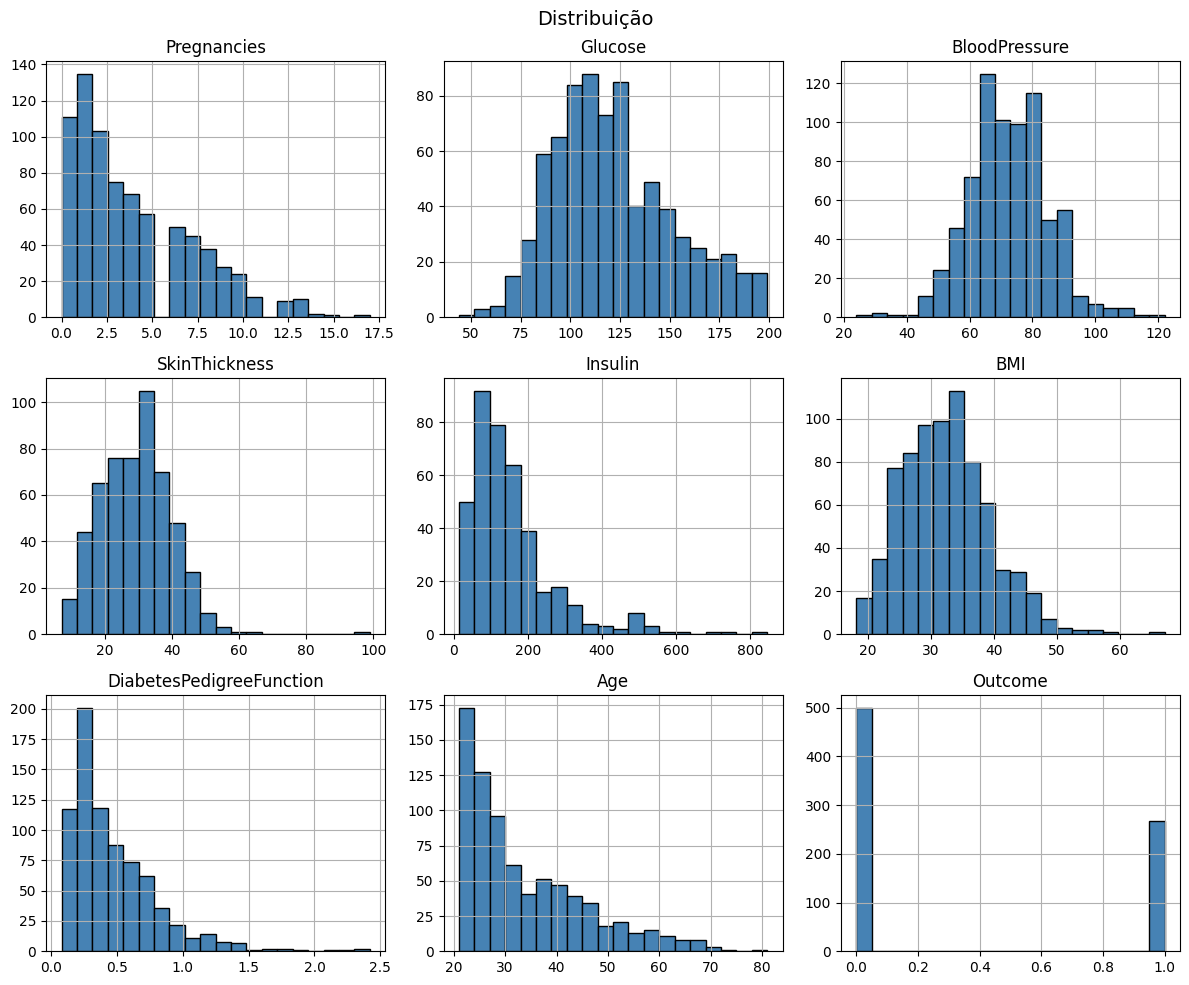

In [13]:
file.hist(figsize=(12,10), bins=20, color='steelblue',edgecolor='black')
plt.suptitle('Distribuição', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/figures/distribuicoes.png')
plt.show

## Correlação das variáveis
Agora é importante entender se essas variáveis estão correlacionadas uma com as outras. 

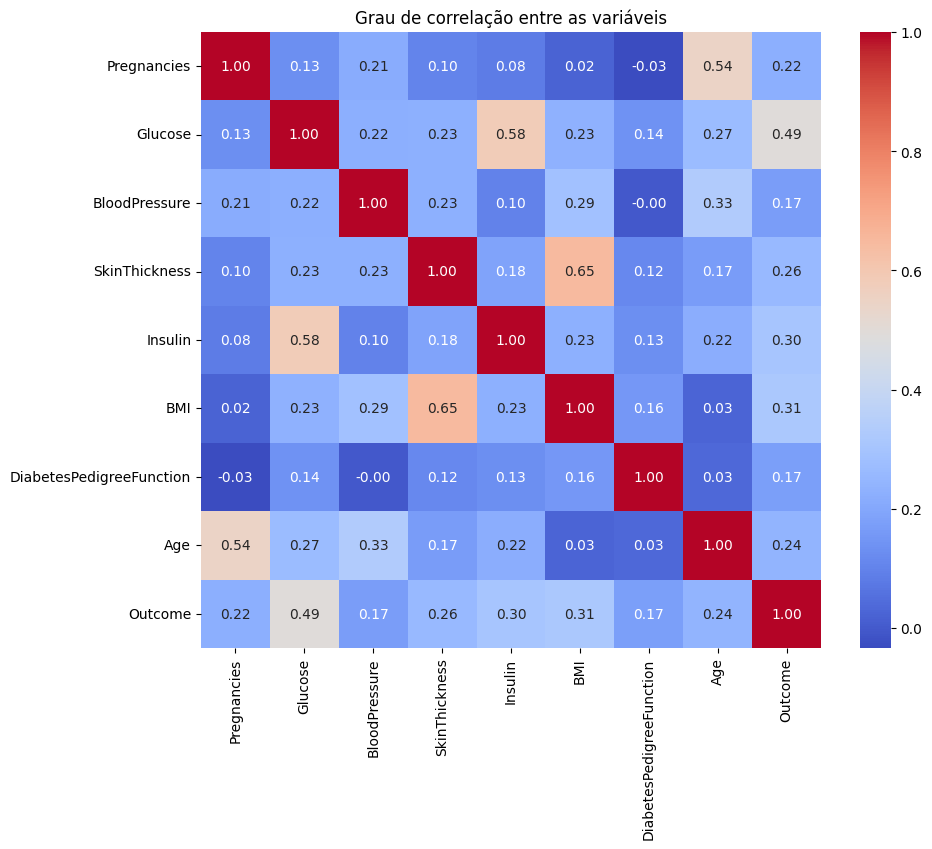

In [18]:
plt.figure(figsize=(10, 8))
sns.heatmap(file.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Grau de correlação entre as variáveis')
plt.savefig('../reports/figures/corrrelaçãovariaveis.png')

## Desbalanecamento. 

In [19]:
count = file['Outcome'].value_counts()
percent = file['Outcome'].value_counts(normalize=True) * 100

print("Contagem:")
print(count)
print("\nPercentual:")
print(percent.round(1))

Contagem:
Outcome
0    500
1    268
Name: count, dtype: int64

Percentual:
Outcome
0    65.1
1    34.9
Name: proportion, dtype: float64


In [ ]:
sns